In [ ]:
# =========================================================
# PsyFormer / ConvTransformer Hybrid
# Leakage Detection + Training Curves + 5-Fold CV + SHAP/LIME
# Multi-task Ordinal Prediction: Anxiety + Depression
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_absolute_error, confusion_matrix, classification_report,
    cohen_kappa_score, matthews_corrcoef
)

import seaborn as sns

In [ ]:
# =========================================================
# 1. Configuration
# =========================================================

DATA_PATH = "/content/Processed.csv"

# MODE = "assessment": uses PSS + GAD + PHQ + demographics
# MODE = "strict": uses only PSS + demographics to avoid label-construction overlap
MODE = "assessment"

SEED = 42
BATCH_SIZE = 32
TEST_BATCH_SIZE = 64
EPOCHS = 100
LR = 2e-4
PATIENCE = 20
TASK_WEIGHTS = (1.0, 1.1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

Using device: cuda


In [ ]:
# =========================================================
# 2. Load Dataset
# =========================================================

df = pd.read_csv(DATA_PATH)
data = df.copy()
data.columns = [c.strip() for c in data.columns]

print("Dataset shape:", data.shape)
print("Columns:")
print(data.columns.tolist())

Dataset shape: (2028, 39)
Columns:
['Age', 'Gender', 'University', 'Department', 'Academic_Year', 'Current_CGPA', 'waiver_or_scholarship', 'PSS1', 'PSS2', 'PSS3', 'PSS4', 'PSS5', 'PSS6', 'PSS7', 'PSS8', 'PSS9', 'PSS10', 'Stress Value', 'Stress Label', 'GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7', 'Anxiety Value', 'Anxiety Label', 'PHQ1', 'PHQ2', 'PHQ3', 'PHQ4', 'PHQ5', 'PHQ6', 'PHQ7', 'PHQ8', 'PHQ9', 'Depression Value', 'Depression Label']


In [ ]:
# =========================================================
# 3. Column Definition
# =========================================================

pss_cols = [f"PSS{i}" for i in range(1, 11)]
gad_cols = [f"GAD{i}" for i in range(1, 8)]
phq_cols = [f"PHQ{i}" for i in range(1, 10)]

demographic_cols = [
    "Age", "Gender", "University", "Department",
    "Academic_Year", "Current_CGPA", "waiver_or_scholarship"
]

target_label_cols = ["Anxiety Label", "Depression Label"]
target_num_cols = ["Anxiety_Target", "Depression_Target"]

explicit_leakage_cols = [
    "Stress Value", "Stress Label", "Stress_Target",
    "Anxiety Value", "Anxiety Label", "Anxiety_Target",
    "Depression Value", "Depression Label", "Depression_Target",
    "Joint_Target"
]

required_cols = pss_cols + gad_cols + phq_cols + demographic_cols + target_label_cols
missing_cols = [c for c in required_cols if c not in data.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")


In [ ]:

# =========================================================
# 4. Target Cleaning and Mapping
# =========================================================

def clean_text(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip()

def map_anxiety_label(x):
    x = str(x).strip().lower()
    if x == "minimal anxiety":
        return 0
    elif x == "mild anxiety":
        return 1
    elif x == "moderate anxiety":
        return 2
    elif x == "severe anxiety":
        return 3
    return np.nan

def map_depression_label(x):
    x = str(x).strip().lower()
    if x in ["no depression", "minimal depression"]:
        return 0
    elif x == "mild depression":
        return 1
    elif x == "moderate depression":
        return 2
    elif x in ["moderately severe depression", "severe depression"]:
        return 3
    return np.nan

for col in demographic_cols + target_label_cols:
    data[col] = data[col].apply(clean_text)

data["Anxiety_Target"] = data["Anxiety Label"].apply(map_anxiety_label)
data["Depression_Target"] = data["Depression Label"].apply(map_depression_label)

data = data.dropna(subset=target_num_cols).reset_index(drop=True)
data["Anxiety_Target"] = data["Anxiety_Target"].astype(int)
data["Depression_Target"] = data["Depression_Target"].astype(int)

data["Joint_Target"] = (
    data["Anxiety_Target"].astype(str) + "_" +
    data["Depression_Target"].astype(str)
)

print("\nTarget distribution:")
print("\nAnxiety:")
print(data["Anxiety_Target"].value_counts().sort_index())
print("\nDepression:")
print(data["Depression_Target"].value_counts().sort_index())


Target distribution:

Anxiety:
Anxiety_Target
0    159
1    505
2    620
3    744
Name: count, dtype: int64

Depression:
Depression_Target
0     141
1     414
2     457
3    1016
Name: count, dtype: int64


In [ ]:
# =========================================================
# Remove exact duplicate rows to reduce train-test overlap risk
# =========================================================
feature_check_cols = pss_cols + gad_cols + phq_cols + demographic_cols + target_num_cols

before = data.shape[0]
data = data.drop_duplicates(subset=feature_check_cols).reset_index(drop=True)
after = data.shape[0]

print(f"Removed duplicate rows: {before - after}")
print("Shape after duplicate removal:", data.shape)

Removed duplicate rows: 6
Shape after duplicate removal: (2022, 42)


In [ ]:
# =========================================================
# 5. Leakage Detection Functions
# =========================================================

def remove_explicit_leakage(feature_cols):
    return [c for c in feature_cols if c not in explicit_leakage_cols]

def detect_explicit_leakage_columns(feature_cols):
    found = [c for c in feature_cols if c in explicit_leakage_cols]
    print("\n[Leakage Check 1] Explicit leakage columns in features:")
    print(found if found else "None")
    return found

def detect_duplicate_rows(df_in, feature_cols):
    duplicated_count = df_in.duplicated(subset=feature_cols).sum()
    print("\n[Leakage Check 2] Duplicate feature rows in full dataset:")
    print("Duplicate rows:", duplicated_count)
    return duplicated_count

def detect_train_test_overlap(train_df, test_df, feature_cols):
    train_hash = pd.util.hash_pandas_object(train_df[feature_cols], index=False)
    test_hash = pd.util.hash_pandas_object(test_df[feature_cols], index=False)
    overlap = set(train_hash).intersection(set(test_hash))

    print("\n[Leakage Check 3] Exact train-test feature overlap:")
    print("Overlapping rows:", len(overlap))
    return len(overlap)

def gad_rule(score):
    if score <= 4:
        return 0
    elif score <= 9:
        return 1
    elif score <= 14:
        return 2
    return 3

def phq_rule(score):
    if score <= 4:
        return 0
    elif score <= 9:
        return 1
    elif score <= 14:
        return 2
    return 3

def detect_label_construction_overlap(df_in):
    temp = df_in.copy()

    for col in gad_cols + phq_cols:
        temp[col] = pd.to_numeric(temp[col], errors="coerce").fillna(0)

    temp["GAD_sum"] = temp[gad_cols].sum(axis=1)
    temp["PHQ_sum"] = temp[phq_cols].sum(axis=1)

    temp["Anxiety_rule_pred"] = temp["GAD_sum"].apply(gad_rule)
    temp["Depression_rule_pred"] = temp["PHQ_sum"].apply(phq_rule)

    anx_acc = accuracy_score(temp["Anxiety_Target"], temp["Anxiety_rule_pred"])
    dep_acc = accuracy_score(temp["Depression_Target"], temp["Depression_rule_pred"])

    print("\n[Leakage Check 4] Label-construction overlap:")
    print("GAD sum -> Anxiety target rule accuracy:", round(anx_acc, 4))
    print("PHQ sum -> Depression target rule accuracy:", round(dep_acc, 4))

    if anx_acc > 0.95:
        print("Warning: Anxiety target is highly reconstructable from GAD items.")
    if dep_acc > 0.95:
        print("Warning: Depression target is highly reconstructable from PHQ items.")

    return anx_acc, dep_acc


In [ ]:
# =========================================================
# 6. Feature Setup
# =========================================================

if MODE == "assessment":
    symptom_cols = pss_cols + gad_cols + phq_cols
elif MODE == "strict":
    symptom_cols = pss_cols
else:
    raise ValueError("MODE must be either 'assessment' or 'strict'.")

feature_cols = remove_explicit_leakage(symptom_cols + demographic_cols)

print("\nRunning mode:", MODE)
print("Symptom columns used:", symptom_cols)
print("Total feature columns:", len(feature_cols))

detect_explicit_leakage_columns(feature_cols)
detect_duplicate_rows(data, feature_cols)
detect_label_construction_overlap(data)



Running mode: assessment
Symptom columns used: ['PSS1', 'PSS2', 'PSS3', 'PSS4', 'PSS5', 'PSS6', 'PSS7', 'PSS8', 'PSS9', 'PSS10', 'GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7', 'PHQ1', 'PHQ2', 'PHQ3', 'PHQ4', 'PHQ5', 'PHQ6', 'PHQ7', 'PHQ8', 'PHQ9']
Total feature columns: 33

[Leakage Check 1] Explicit leakage columns in features:
None

[Leakage Check 2] Duplicate feature rows in full dataset:
Duplicate rows: 0

[Leakage Check 4] Label-construction overlap:
GAD sum -> Anxiety target rule accuracy: 1.0
PHQ sum -> Depression target rule accuracy: 1.0


(1.0, 1.0)

You have **two types of issues** here:

### 1. Duplicate rows: 6

This is small, but remove duplicates before splitting:

```python
data = data.drop_duplicates(subset=feature_cols + target_num_cols).reset_index(drop=True)
print("Shape after duplicate removal:", data.shape)
```

### 2. Label-construction overlap: 1.0

This is the important one.

It means:

```text
GAD1–GAD7 fully reconstruct Anxiety_Target
PHQ1–PHQ9 fully reconstruct Depression_Target
```

So if you keep `MODE = "assessment"`, your model is mainly learning the scoring rule. This is acceptable only if you describe the project as **questionnaire-based severity assessment**, not independent early prediction.

For a stronger leakage-safe experiment, use:

```python
MODE = "strict"
```

This will use:

```text
PSS + demographics only
```

and remove direct GAD/PHQ target overlap.

Better option for your stress-guided claim:

```python
# Anxiety prediction features
anxiety_symptom_cols = pss_cols + phq_cols

# Depression prediction features
depression_symptom_cols = pss_cols + gad_cols
```

But your current model has one shared input for both tasks, so the simplest clean option is:

```python
MODE = "strict"
```

### What I recommend for your paper/report

Use both experiments:

```text
Assessment setting:
PSS + GAD + PHQ + demographics
Shows high performance for severity assessment.

Strict stress-guided setting:
PSS + demographics only
Shows prediction without direct target-overlap.
```

Then write clearly:

> The assessment setting may contain psychometric target overlap because GAD and PHQ items are used to derive the target severity labels. Therefore, an additional strict setting was evaluated using only stress-related and demographic features to reduce label-construction leakage.


In [ ]:

# =========================================================
# 7. Metrics and Helpers
# =========================================================

def quadratic_weighted_kappa(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights="quadratic")

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "mae": mean_absolute_error(y_true, y_pred),
        "qwk": quadratic_weighted_kappa(y_true, y_pred),
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred)
    }

def ordinal_encoding(label, num_classes=4):
    return torch.tensor(
        [1.0 if label > k else 0.0 for k in range(num_classes - 1)],
        dtype=torch.float
    )

def logits_to_class(logits):
    probs = torch.sigmoid(logits)
    preds = torch.sum(probs, dim=1).round().long()
    return torch.clamp(preds, 0, 3)

def get_class_weights(y_array):
    classes = np.unique(y_array)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_array
    )
    return {int(c): float(w) for c, w in zip(classes, weights)}

def weighted_coral_loss(logits, ordinal_targets, class_labels, class_weight_dict):
    bce = F.binary_cross_entropy_with_logits(logits, ordinal_targets, reduction="none")
    sample_loss = bce.mean(dim=1)

    weights = torch.tensor(
        [class_weight_dict[int(c.item())] for c in class_labels],
        dtype=torch.float,
        device=logits.device
    )

    return (sample_loss * weights).mean()


In [ ]:

# =========================================================
# 8. Preprocessing Function
# Fit only on train, transform test/validation
# =========================================================

def preprocess_split(train_df, test_df, symptom_cols, demographic_cols):
    try:
        pd.to_numeric(train_df["Age"], errors="raise")
        age_as_numeric = True
    except:
        age_as_numeric = False

    if age_as_numeric:
        categorical_demo_cols = [
            "Gender", "University", "Department",
            "Academic_Year", "waiver_or_scholarship"
        ]
        numeric_demo_cols = ["Age", "Current_CGPA"]
    else:
        categorical_demo_cols = [
            "Age", "Gender", "University", "Department",
            "Academic_Year", "waiver_or_scholarship"
        ]
        numeric_demo_cols = ["Current_CGPA"]

    X_train = train_df[symptom_cols + demographic_cols].copy()
    X_test = test_df[symptom_cols + demographic_cols].copy()

    for col in categorical_demo_cols:
        X_train[col] = X_train[col].astype(str).str.strip().replace(
            ["nan", "None", "", "NaN"], "Unknown"
        )
        X_test[col] = X_test[col].astype(str).str.strip().replace(
            ["nan", "None", "", "NaN"], "Unknown"
        )

    for col in symptom_cols + numeric_demo_cols:
        X_train[col] = pd.to_numeric(X_train[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
        X_test[col] = pd.to_numeric(X_test[col], errors="coerce").replace([np.inf, -np.inf], np.nan)

    symptom_imputer = SimpleImputer(strategy="median")
    X_train_symptom = symptom_imputer.fit_transform(X_train[symptom_cols])
    X_test_symptom = symptom_imputer.transform(X_test[symptom_cols])

    symptom_scaler = StandardScaler()
    X_train_symptom = symptom_scaler.fit_transform(X_train_symptom)
    X_test_symptom = symptom_scaler.transform(X_test_symptom)

    label_encoders = {}
    for col in categorical_demo_cols:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))

        known = set(le.classes_)
        fallback = le.classes_[0]

        X_test[col] = X_test[col].apply(lambda x: x if x in known else fallback)
        X_test[col] = le.transform(X_test[col].astype(str))

        label_encoders[col] = le

    demo_cols = numeric_demo_cols + categorical_demo_cols

    demo_imputer = SimpleImputer(strategy="median")
    X_train_demo = demo_imputer.fit_transform(X_train[demo_cols])
    X_test_demo = demo_imputer.transform(X_test[demo_cols])

    demo_scaler = StandardScaler()
    X_train_demo = demo_scaler.fit_transform(X_train_demo)
    X_test_demo = demo_scaler.transform(X_test_demo)

    preprocessors = {
        "symptom_imputer": symptom_imputer,
        "symptom_scaler": symptom_scaler,
        "demo_imputer": demo_imputer,
        "demo_scaler": demo_scaler,
        "label_encoders": label_encoders,
        "demo_cols": demo_cols
    }

    return X_train_symptom, X_test_symptom, X_train_demo, X_test_demo, demo_cols, preprocessors


In [ ]:

# =========================================================
# 9. Dataset Class
# =========================================================

class MultiTaskTabularDataset(Dataset):
    def __init__(self, X_symptom, X_demo, y_anx, y_dep):
        self.X_symptom = torch.tensor(X_symptom, dtype=torch.float)
        self.X_demo = torch.tensor(X_demo, dtype=torch.float)
        self.y_anx = torch.tensor(y_anx, dtype=torch.long)
        self.y_dep = torch.tensor(y_dep, dtype=torch.long)

    def __len__(self):
        return len(self.X_symptom)

    def __getitem__(self, idx):
        return {
            "x_symptom": self.X_symptom[idx],
            "x_demo": self.X_demo[idx],
            "y_anx": self.y_anx[idx],
            "y_dep": self.y_dep[idx],
            "y_anx_ord": ordinal_encoding(int(self.y_anx[idx].item()), 4),
            "y_dep_ord": ordinal_encoding(int(self.y_dep[idx].item()), 4)
        }


In [ ]:


# =========================================================
# 10. Proposed Model: ConvTransformer Hybrid / PsyFormer
# =========================================================

class ConvTransformerHybrid(nn.Module):
    def __init__(self, seq_len, demo_dim, d_model=96, nhead=4, num_layers=4, dropout=0.35):
        super().__init__()

        self.seq_len = seq_len
        self.d_model = d_model

        self.value_proj = nn.Linear(1, d_model)
        self.feature_embedding = nn.Parameter(torch.randn(1, seq_len, d_model))
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_len, d_model))

        self.cnn = nn.Sequential(
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1),
            nn.BatchNorm1d(d_model),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Conv1d(d_model, d_model, kernel_size=5, padding=2),
            nn.BatchNorm1d(d_model),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.pre_gate = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.Sigmoid()
        )

        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.attn_pool = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.Tanh(),
            nn.Linear(d_model // 2, 1)
        )

        self.demo_mlp = nn.Sequential(
            nn.Linear(demo_dim, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.GELU()
        )

        shared_dim = d_model + 16

        self.final_gate = nn.Sequential(
            nn.Linear(shared_dim, shared_dim),
            nn.Sigmoid()
        )

        self.anx_head = nn.Sequential(
            nn.Linear(shared_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

        self.dep_head = nn.Sequential(
            nn.Linear(shared_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

    def forward_features(self, x_symptom, x_demo):
        B = x_symptom.size(0)

        x = x_symptom.unsqueeze(-1)
        x = self.value_proj(x)
        x = x + self.feature_embedding + self.pos_embedding

        raw_tokens = x

        cnn_out = self.cnn(x.transpose(1, 2)).transpose(1, 2)

        pre_gate = self.pre_gate(torch.cat([x, cnn_out], dim=-1))
        x = pre_gate * x + (1 - pre_gate) * cnn_out

        tokens_before_cls = x

        cls = self.cls_token.repeat(B, 1, 1)
        x = torch.cat([cls, x], dim=1)

        x = self.transformer(x)

        cls_repr = x[:, 0, :]
        token_repr = x[:, 1:, :]

        attn_scores = self.attn_pool(token_repr)
        attn_weights = torch.softmax(attn_scores, dim=1)
        pooled_repr = torch.sum(attn_weights * token_repr, dim=1)

        symptom_repr = 0.5 * cls_repr + 0.5 * pooled_repr
        demo_repr = self.demo_mlp(x_demo)

        fused = torch.cat([symptom_repr, demo_repr], dim=1)
        final_gate = self.final_gate(fused)
        fused = fused * final_gate

        feats = {
            "raw_tokens": raw_tokens,
            "cnn_out": cnn_out,
            "pre_gate": pre_gate,
            "tokens_before_cls": tokens_before_cls,
            "token_repr": token_repr,
            "cls_repr": cls_repr,
            "attn_scores": attn_scores,
            "attn_weights": attn_weights,
            "pooled_repr": pooled_repr,
            "demo_repr": demo_repr,
            "final_gate": final_gate,
            "fused_repr": fused
        }

        return fused, feats

    def forward(self, x_symptom, x_demo):
        fused, _ = self.forward_features(x_symptom, x_demo)
        anx_logits = self.anx_head(fused)
        dep_logits = self.dep_head(fused)
        return anx_logits, dep_logits

    def forward_with_explanations(self, x_symptom, x_demo):
        fused, feats = self.forward_features(x_symptom, x_demo)
        anx_logits = self.anx_head(fused)
        dep_logits = self.dep_head(fused)
        return anx_logits, dep_logits, feats



In [ ]:

# =========================================================
# 11. Evaluation Function
# =========================================================

def evaluate_model(model, loader, return_loss=False, anx_class_weights=None, dep_class_weights=None):
    model.eval()

    anx_true, anx_pred = [], []
    dep_true, dep_pred = [], []
    total_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for batch in loader:
            x_symptom = batch["x_symptom"].to(device)
            x_demo = batch["x_demo"].to(device)
            y_anx = batch["y_anx"].to(device)
            y_dep = batch["y_dep"].to(device)
            y_anx_ord = batch["y_anx_ord"].to(device)
            y_dep_ord = batch["y_dep_ord"].to(device)

            anx_logits, dep_logits = model(x_symptom, x_demo)

            if return_loss:
                loss_anx = weighted_coral_loss(anx_logits, y_anx_ord, y_anx, anx_class_weights)
                loss_dep = weighted_coral_loss(dep_logits, y_dep_ord, y_dep, dep_class_weights)
                loss = TASK_WEIGHTS[0] * loss_anx + TASK_WEIGHTS[1] * loss_dep
                total_loss += loss.item()
                n_batches += 1

            pred_anx = logits_to_class(anx_logits)
            pred_dep = logits_to_class(dep_logits)

            anx_true.extend(y_anx.cpu().numpy())
            anx_pred.extend(pred_anx.cpu().numpy())

            dep_true.extend(y_dep.cpu().numpy())
            dep_pred.extend(pred_dep.cpu().numpy())

    output = {
        "anxiety": compute_metrics(anx_true, anx_pred),
        "depression": compute_metrics(dep_true, dep_pred),
        "anxiety_true": anx_true,
        "anxiety_pred": anx_pred,
        "depression_true": dep_true,
        "depression_pred": dep_pred
    }

    if return_loss:
        output["loss"] = total_loss / max(1, n_batches)

    return output


In [ ]:


# =========================================================
# 12. Training Function with Train/Test Curves
# =========================================================

def train_model(
    model,
    train_loader,
    val_loader,
    anx_class_weights,
    dep_class_weights,
    epochs=EPOCHS,
    lr=LR,
    patience=PATIENCE
):
    model = model.to(device)

    # optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4) #from 1e-4
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=5
    )

    best_state = None
    best_score = -1
    wait = 0

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_total = 0.0

        for batch in train_loader:
            x_symptom = batch["x_symptom"].to(device)
            x_demo = batch["x_demo"].to(device)
            y_anx = batch["y_anx"].to(device)
            y_dep = batch["y_dep"].to(device)
            y_anx_ord = batch["y_anx_ord"].to(device)
            y_dep_ord = batch["y_dep_ord"].to(device)

            optimizer.zero_grad()

            anx_logits, dep_logits = model(x_symptom, x_demo)

            loss_anx = weighted_coral_loss(anx_logits, y_anx_ord, y_anx, anx_class_weights)
            loss_dep = weighted_coral_loss(dep_logits, y_dep_ord, y_dep, dep_class_weights)

            loss = TASK_WEIGHTS[0] * loss_anx + TASK_WEIGHTS[1] * loss_dep
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss_total += loss.item()

        train_eval = evaluate_model(
            model, train_loader, return_loss=True,
            anx_class_weights=anx_class_weights,
            dep_class_weights=dep_class_weights
        )

        val_eval = evaluate_model(
            model, val_loader, return_loss=True,
            anx_class_weights=anx_class_weights,
            dep_class_weights=dep_class_weights
        )

        train_avg_f1 = (train_eval["anxiety"]["macro_f1"] + train_eval["depression"]["macro_f1"]) / 2
        val_avg_f1 = (val_eval["anxiety"]["macro_f1"] + val_eval["depression"]["macro_f1"]) / 2

        train_avg_acc = (train_eval["anxiety"]["accuracy"] + train_eval["depression"]["accuracy"]) / 2
        val_avg_acc = (val_eval["anxiety"]["accuracy"] + val_eval["depression"]["accuracy"]) / 2

        scheduler.step(val_avg_f1)

        history.append({
            "epoch": epoch,

            "train_loss": train_eval["loss"],
            "val_loss": val_eval["loss"],

            "train_anx_acc": train_eval["anxiety"]["accuracy"],
            "train_dep_acc": train_eval["depression"]["accuracy"],
            "train_avg_acc": train_avg_acc,

            "val_anx_acc": val_eval["anxiety"]["accuracy"],
            "val_dep_acc": val_eval["depression"]["accuracy"],
            "val_avg_acc": val_avg_acc,

            "train_anx_f1": train_eval["anxiety"]["macro_f1"],
            "train_dep_f1": train_eval["depression"]["macro_f1"],
            "train_avg_f1": train_avg_f1,

            "val_anx_f1": val_eval["anxiety"]["macro_f1"],
            "val_dep_f1": val_eval["depression"]["macro_f1"],
            "val_avg_f1": val_avg_f1,
        })

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:03d} | "
                f"Train Loss: {train_eval['loss']:.4f} | "
                f"Val Loss: {val_eval['loss']:.4f} | "
                f"Train Avg F1: {train_avg_f1:.4f} | "
                f"Val Avg F1: {val_avg_f1:.4f}"
            )

        if val_avg_f1 > best_score:
            best_score = val_avg_f1
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)

In [ ]:

# =========================================================
# 13. Plot Curves
# =========================================================

def plot_all_training_curves(history_df):
    plt.figure(figsize=(18, 5))



    plt.subplot(1, 3, 1)
    plt.plot(history_df["epoch"], history_df["train_avg_acc"], label="Train Avg Accuracy", linewidth=2)
    plt.plot(history_df["epoch"], history_df["val_avg_acc"], label="Val Avg Accuracy", linewidth=2)
    plt.plot(history_df["epoch"], history_df["val_anx_acc"], label="Val Anxiety Accuracy", alpha=0.7)
    plt.plot(history_df["epoch"], history_df["val_dep_acc"], label="Val Depression Accuracy", alpha=0.7)
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss", linewidth=2)
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss", linewidth=2)
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(history_df["epoch"], history_df["train_avg_f1"], label="Train Avg Macro-F1", linewidth=2)
    plt.plot(history_df["epoch"], history_df["val_avg_f1"], label="Val Avg Macro-F1", linewidth=2)
    plt.plot(history_df["epoch"], history_df["val_anx_f1"], label="Val Anxiety F1", alpha=0.7)
    plt.plot(history_df["epoch"], history_df["val_dep_f1"], label="Val Depression F1", alpha=0.7)
    plt.title("Macro-F1 Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


Using joint stratification

[Leakage Check 3] Exact train-test feature overlap:
Overlapping rows: 0

Anxiety class weights: {0: 3.1830708661417324, 1: 1.0081047381546135, 2: 0.8150201612903226, 3: 0.6817032040472175}
Depression class weights: {0: 3.609375, 1: 1.2287234042553192, 2: 1.1105769230769231, 3: 0.4978448275862069}
Epoch 001 | Train Loss: 0.8564 | Val Loss: 0.8669 | Train Avg F1: 0.2515 | Val Avg F1: 0.2487
Epoch 010 | Train Loss: 0.3310 | Val Loss: 0.3740 | Train Avg F1: 0.7775 | Val Avg F1: 0.7773
Epoch 020 | Train Loss: 0.0962 | Val Loss: 0.1173 | Train Avg F1: 0.9287 | Val Avg F1: 0.9047
Epoch 030 | Train Loss: 0.0583 | Val Loss: 0.0751 | Train Avg F1: 0.9543 | Val Avg F1: 0.9441
Epoch 040 | Train Loss: 0.0407 | Val Loss: 0.0623 | Train Avg F1: 0.9707 | Val Avg F1: 0.9578
Epoch 050 | Train Loss: 0.0305 | Val Loss: 0.0482 | Train Avg F1: 0.9874 | Val Avg F1: 0.9731
Epoch 060 | Train Loss: 0.0355 | Val Loss: 0.0589 | Train Avg F1: 0.9774 | Val Avg F1: 0.9629
Epoch 070 | Tra

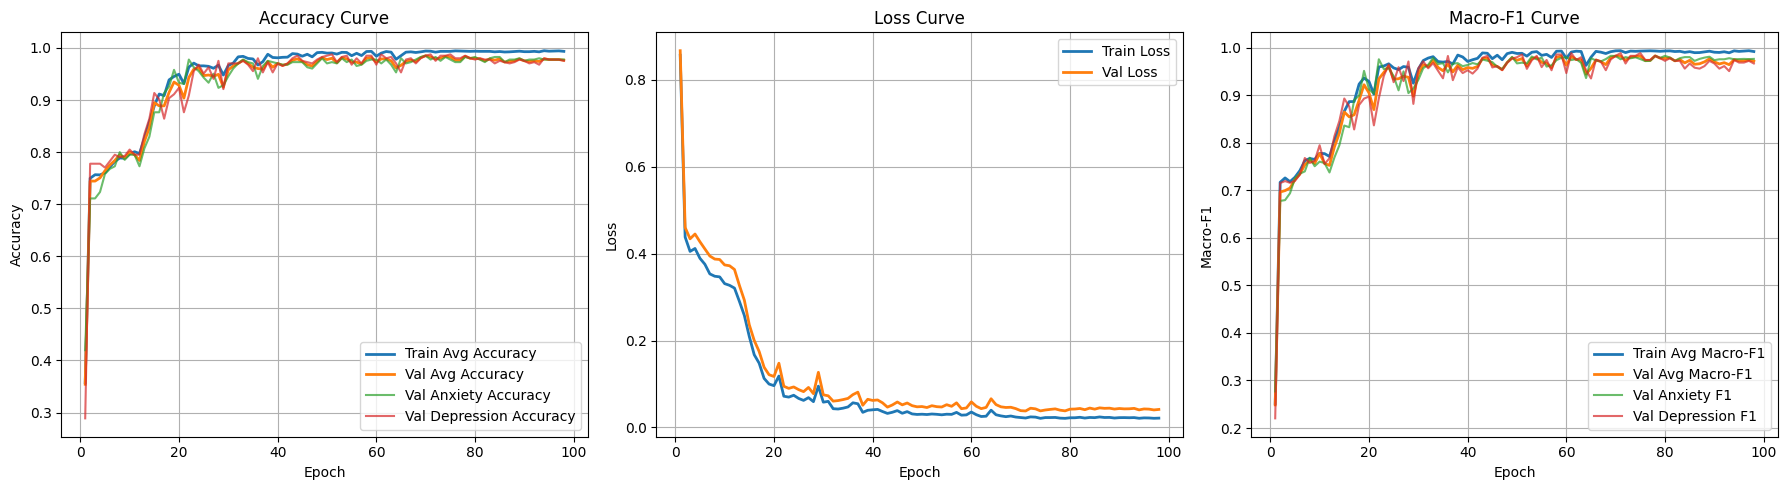

In [ ]:

# =========================================================
# 14. Single Train-Test Experiment
# =========================================================

joint_labels = data[["Anxiety_Target", "Depression_Target"]].astype(str).agg("_".join, axis=1)

indices = np.arange(len(data))

if joint_labels.value_counts().min() >= 2:
    stratify_key = joint_labels
    print("\nUsing joint stratification")
else:
    stratify_key = data["Anxiety_Target"]
    print("\nFallback to Anxiety stratification")

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=SEED,
    stratify=stratify_key
)

train_df = data.iloc[train_idx].reset_index(drop=True)
test_df = data.iloc[test_idx].reset_index(drop=True)

detect_train_test_overlap(train_df, test_df, feature_cols)

X_train_symptom, X_test_symptom, X_train_demo, X_test_demo, demo_cols, preprocessors = preprocess_split(
    train_df, test_df, symptom_cols, demographic_cols
)

y_train_anx = train_df["Anxiety_Target"].values
y_test_anx = test_df["Anxiety_Target"].values
y_train_dep = train_df["Depression_Target"].values
y_test_dep = test_df["Depression_Target"].values

train_dataset = MultiTaskTabularDataset(X_train_symptom, X_train_demo, y_train_anx, y_train_dep)
test_dataset = MultiTaskTabularDataset(X_test_symptom, X_test_demo, y_test_anx, y_test_dep)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=TEST_BATCH_SIZE, shuffle=False)

anx_class_weights = get_class_weights(y_train_anx)
dep_class_weights = get_class_weights(y_train_dep)

print("\nAnxiety class weights:", anx_class_weights)
print("Depression class weights:", dep_class_weights)

conv_transformer_model = ConvTransformerHybrid(
    seq_len=X_train_symptom.shape[1],
    demo_dim=X_train_demo.shape[1],
    d_model=64, #from 96
    nhead=4,
    num_layers=2, # from 4
    dropout=0.35 #change from 0.25
)

conv_transformer_model, history_df = train_model(
    model=conv_transformer_model,
    train_loader=train_loader,
    val_loader=test_loader,
    anx_class_weights=anx_class_weights,
    dep_class_weights=dep_class_weights,
    epochs=EPOCHS,
    lr=LR,
    patience=PATIENCE
)

single_results = evaluate_model(conv_transformer_model, test_loader)

print("\nFinal Test Results:")
print("Anxiety:", single_results["anxiety"])
print("Depression:", single_results["depression"])

plot_all_training_curves(history_df)

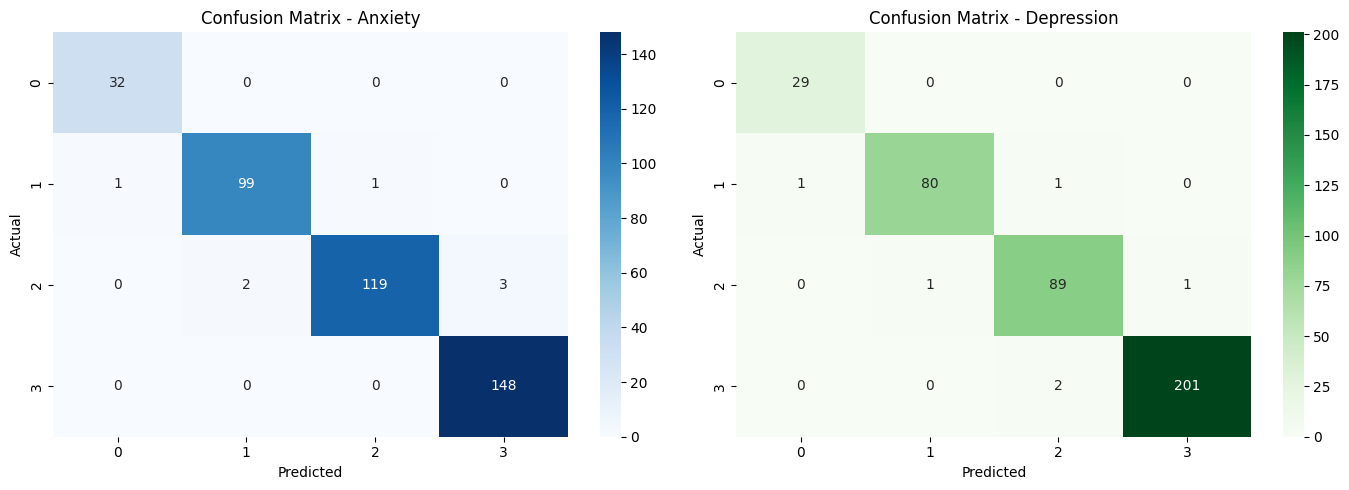

In [ ]:

# =========================================================
# 15. Confusion Matrix
# =========================================================

def plot_confusion_matrices(results):
    cm_anx = confusion_matrix(results["anxiety_true"], results["anxiety_pred"])
    cm_dep = confusion_matrix(results["depression_true"], results["depression_pred"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm_anx, annot=True, fmt="d", cmap="Blues", ax=axes[0])
    axes[0].set_title("Confusion Matrix - Anxiety")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    sns.heatmap(cm_dep, annot=True, fmt="d", cmap="Greens", ax=axes[1])
    axes[1].set_title("Confusion Matrix - Depression")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

plot_confusion_matrices(single_results)


In [ ]:

# =========================================================
# 16. Single Split Summary Table
# =========================================================

single_summary_table = pd.DataFrame([
    {
        "Model": "ConvTransformer Hybrid",
        "Task": "Anxiety",
        "Accuracy": single_results["anxiety"]["accuracy"],
        "Precision": single_results["anxiety"]["precision"],
        "Recall": single_results["anxiety"]["recall"],
        "F1 Score": single_results["anxiety"]["macro_f1"],
        "MAE": single_results["anxiety"]["mae"],
        "QWK": single_results["anxiety"]["qwk"]
    },
    {
        "Model": "ConvTransformer Hybrid",
        "Task": "Depression",
        "Accuracy": single_results["depression"]["accuracy"],
        "Precision": single_results["depression"]["precision"],
        "Recall": single_results["depression"]["recall"],
        "F1 Score": single_results["depression"]["macro_f1"],
        "MAE": single_results["depression"]["mae"],
        "QWK": single_results["depression"]["qwk"]
    }
])

print("\nSingle Split Summary Table:")
print(single_summary_table.round(4))


Single Split Summary Table:
                    Model        Task  Accuracy  Precision  Recall  F1 Score  \
0  ConvTransformer Hybrid     Anxiety    0.9827     0.9804  0.9850    0.9825   
1  ConvTransformer Hybrid  Depression    0.9852     0.9792  0.9859    0.9825   

      MAE     QWK  
0  0.0173  0.9908  
1  0.0148  0.9924  



FOLD 1

[Leakage Check 3] Exact train-test feature overlap:
Overlapping rows: 0
Epoch 001 | Train Loss: 0.4820 | Val Loss: 0.4948 | Train Avg F1: 0.7163 | Val Avg F1: 0.7082
Epoch 010 | Train Loss: 0.1091 | Val Loss: 0.1278 | Train Avg F1: 0.9231 | Val Avg F1: 0.9081
Epoch 020 | Train Loss: 0.0716 | Val Loss: 0.1024 | Train Avg F1: 0.9422 | Val Avg F1: 0.9186
Epoch 030 | Train Loss: 0.0537 | Val Loss: 0.0997 | Train Avg F1: 0.9591 | Val Avg F1: 0.9256
Epoch 040 | Train Loss: 0.0150 | Val Loss: 0.0527 | Train Avg F1: 0.9949 | Val Avg F1: 0.9669
Epoch 050 | Train Loss: 0.0109 | Val Loss: 0.0431 | Train Avg F1: 0.9966 | Val Avg F1: 0.9735
Epoch 060 | Train Loss: 0.0149 | Val Loss: 0.0596 | Train Avg F1: 0.9895 | Val Avg F1: 0.9602
Early stopping triggered.

FOLD 2

[Leakage Check 3] Exact train-test feature overlap:
Overlapping rows: 0
Epoch 001 | Train Loss: 0.4719 | Val Loss: 0.4951 | Train Avg F1: 0.7123 | Val Avg F1: 0.6954
Epoch 010 | Train Loss: 0.1420 | Val Loss: 0.1367 | Train Av

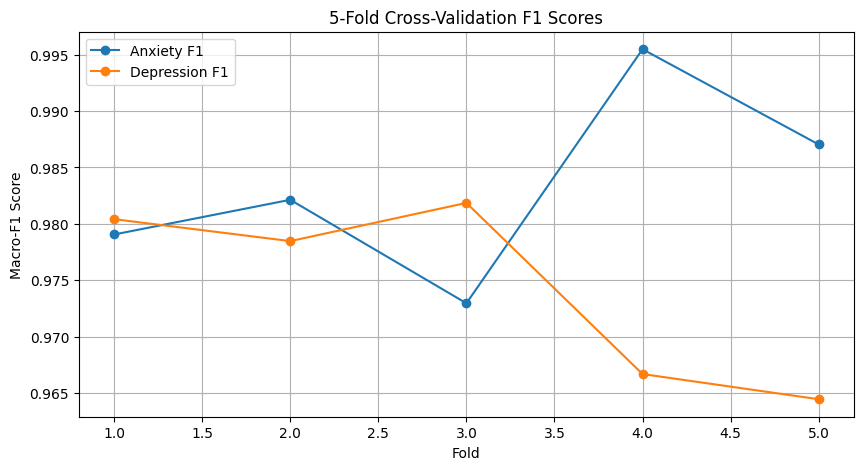

In [ ]:

# =========================================================
# 17. 5-Fold Cross Validation
# =========================================================

def run_5fold_cv(data, symptom_cols, demographic_cols):
    joint_labels = data[["Anxiety_Target", "Depression_Target"]].astype(str).agg("_".join, axis=1)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(data, joint_labels), start=1):
        print("\n" + "=" * 80)
        print(f"FOLD {fold}")
        print("=" * 80)

        train_df = data.iloc[train_idx].reset_index(drop=True)
        val_df = data.iloc[val_idx].reset_index(drop=True)

        detect_train_test_overlap(train_df, val_df, symptom_cols + demographic_cols)

        X_train_symptom, X_val_symptom, X_train_demo, X_val_demo, demo_cols, _ = preprocess_split(
            train_df, val_df, symptom_cols, demographic_cols
        )

        y_train_anx = train_df["Anxiety_Target"].values
        y_val_anx = val_df["Anxiety_Target"].values
        y_train_dep = train_df["Depression_Target"].values
        y_val_dep = val_df["Depression_Target"].values

        train_dataset = MultiTaskTabularDataset(X_train_symptom, X_train_demo, y_train_anx, y_train_dep)
        val_dataset = MultiTaskTabularDataset(X_val_symptom, X_val_demo, y_val_anx, y_val_dep)

        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=TEST_BATCH_SIZE, shuffle=False)

        anx_class_weights = get_class_weights(y_train_anx)
        dep_class_weights = get_class_weights(y_train_dep)

        model = ConvTransformerHybrid(
            seq_len=X_train_symptom.shape[1],
            demo_dim=X_train_demo.shape[1],
            d_model=96,
            nhead=4,
            num_layers=4,
            dropout=0.35
        )

        model, fold_history = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            anx_class_weights=anx_class_weights,
            dep_class_weights=dep_class_weights,
            epochs=EPOCHS,
            lr=LR,
            patience=PATIENCE
        )

        fold_eval = evaluate_model(model, val_loader)

        fold_results.append({
            "fold": fold,

            "anxiety_accuracy": fold_eval["anxiety"]["accuracy"],
            "anxiety_precision": fold_eval["anxiety"]["precision"],
            "anxiety_recall": fold_eval["anxiety"]["recall"],
            "anxiety_f1": fold_eval["anxiety"]["macro_f1"],

            "depression_accuracy": fold_eval["depression"]["accuracy"],
            "depression_precision": fold_eval["depression"]["precision"],
            "depression_recall": fold_eval["depression"]["recall"],
            "depression_f1": fold_eval["depression"]["macro_f1"]
        })

    cv_results_df = pd.DataFrame(fold_results)

    final_cv_table = pd.DataFrame({
        "Task": ["Anxiety", "Depression"],
        "Accuracy": [
            f"{cv_results_df['anxiety_accuracy'].mean():.4f} ± {cv_results_df['anxiety_accuracy'].std():.4f}",
            f"{cv_results_df['depression_accuracy'].mean():.4f} ± {cv_results_df['depression_accuracy'].std():.4f}"
        ],
        "Precision": [
            f"{cv_results_df['anxiety_precision'].mean():.4f} ± {cv_results_df['anxiety_precision'].std():.4f}",
            f"{cv_results_df['depression_precision'].mean():.4f} ± {cv_results_df['depression_precision'].std():.4f}"
        ],
        "Recall": [
            f"{cv_results_df['anxiety_recall'].mean():.4f} ± {cv_results_df['anxiety_recall'].std():.4f}",
            f"{cv_results_df['depression_recall'].mean():.4f} ± {cv_results_df['depression_recall'].std():.4f}"
        ],
        "F1 Score": [
            f"{cv_results_df['anxiety_f1'].mean():.4f} ± {cv_results_df['anxiety_f1'].std():.4f}",
            f"{cv_results_df['depression_f1'].mean():.4f} ± {cv_results_df['depression_f1'].std():.4f}"
        ]
    })

    print("\nPer-fold results:")
    print(cv_results_df.round(4))

    print("\nFinal 5-Fold CV Summary Table:")
    print(final_cv_table)

    plt.figure(figsize=(10, 5))
    plt.plot(cv_results_df["fold"], cv_results_df["anxiety_f1"], marker="o", label="Anxiety F1")
    plt.plot(cv_results_df["fold"], cv_results_df["depression_f1"], marker="o", label="Depression F1")
    plt.xlabel("Fold")
    plt.ylabel("Macro-F1 Score")
    plt.title("5-Fold Cross-Validation F1 Scores")
    plt.legend()
    plt.grid(True)
    plt.show()

    return cv_results_df, final_cv_table

cv_results_df, final_cv_table = run_5fold_cv(data, symptom_cols, demographic_cols)


In [ ]:
# =========================================================
# 18. Ordinal Logits to Class Probabilities
# Required for SHAP/LIME
# =========================================================

def ordinal_logits_to_probs(logits):
    cum_probs = torch.sigmoid(logits)

    p0 = 1.0 - cum_probs[:, 0]
    p1 = cum_probs[:, 0] - cum_probs[:, 1]
    p2 = cum_probs[:, 1] - cum_probs[:, 2]
    p3 = cum_probs[:, 2]

    probs = torch.stack([p0, p1, p2, p3], dim=1)
    probs = torch.clamp(probs, min=1e-8)
    probs = probs / probs.sum(dim=1, keepdim=True)

    return probs


In [ ]:
# =========================================================
# 19. LIME and SHAP Preparation
# =========================================================

X_train_all = np.concatenate([X_train_symptom, X_train_demo], axis=1)
X_test_all = np.concatenate([X_test_symptom, X_test_demo], axis=1)

symptom_dim = X_train_symptom.shape[1]
demo_dim = X_train_demo.shape[1]

feature_names = list(symptom_cols) + list(demo_cols)

print("\nX_train_all:", X_train_all.shape)
print("X_test_all:", X_test_all.shape)
print("Feature names:", len(feature_names))

def predict_anxiety_proba(X_flat):
    conv_transformer_model.eval()

    X_flat = np.asarray(X_flat, dtype=np.float32)
    x_symptom = torch.tensor(X_flat[:, :symptom_dim], dtype=torch.float32).to(device)
    x_demo = torch.tensor(X_flat[:, symptom_dim:], dtype=torch.float32).to(device)

    with torch.no_grad():
        anx_logits, _ = conv_transformer_model(x_symptom, x_demo)
        probs = ordinal_logits_to_probs(anx_logits).cpu().numpy()

    return probs

def predict_depression_proba(X_flat):
    conv_transformer_model.eval()

    X_flat = np.asarray(X_flat, dtype=np.float32)
    x_symptom = torch.tensor(X_flat[:, :symptom_dim], dtype=torch.float32).to(device)
    x_demo = torch.tensor(X_flat[:, symptom_dim:], dtype=torch.float32).to(device)

    with torch.no_grad():
        _, dep_logits = conv_transformer_model(x_symptom, x_demo)
        probs = ordinal_logits_to_probs(dep_logits).cpu().numpy()

    return probs


X_train_all: (1617, 32)
X_test_all: (405, 32)
Feature names: 33


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=d26026880b1eb655c85b22e1881b75c8919976d7170f5a10ad11ed6a0f79b4c1
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime

===== LIME Anxiety Explanation =====
Predicted Anxiety Class: 2
[('0.21 < GAD6 <= 1.21', -0.06575748555096468), ('0.23 < GAD1 <= 1.28', -0.0601319852423049), ('GAD2 <= -0.62', -0.03848445260845082), ('0.14 < GAD5 <= 1.16', -0.037359088286830267), ('PHQ8 <= -0.43', -0.03545190644608718), ('PHQ5 <= -0.48', 0.034999578844710666), ('PSS8 <= -0.65', -0.03076373347721393), ('PHQ6 <= -0.72', 0.025558601119378986), ('PSS1 <= -0.30', -0.02186081705813122), ('-1.02 < PHQ9 <= -0.14', -0.021374545352268196), ('-1.23 < Gender <= 0.33', -0.021368458881779188), ('GAD3 <= -0.76', -0.019286753971205658), ('

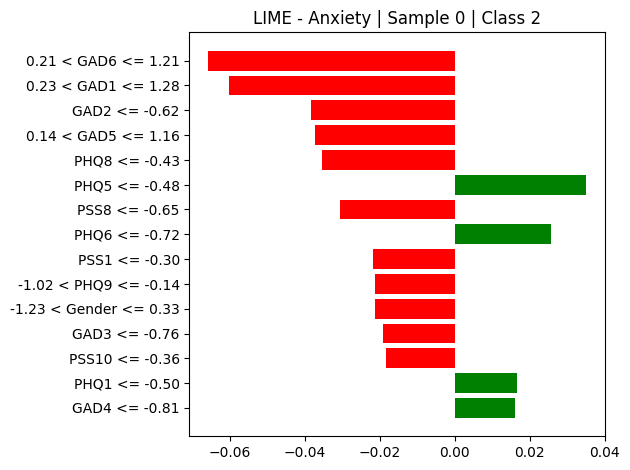


===== LIME Depression Explanation =====
Predicted Depression Class: 1
[('PHQ4 <= -1.00', 0.1198870616644846), ('PHQ3 <= -0.61', 0.09485318265645312), ('PHQ2 <= -0.77', 0.08724291073644898), ('PHQ1 <= -0.50', 0.08508944470750361), ('PHQ7 <= -0.61', 0.0796664476542801), ('PHQ6 <= -0.72', 0.07887550797131909), ('PHQ5 <= -0.48', 0.06916967515438203), ('PHQ8 <= -0.43', 0.06895451813745682), ('GAD7 <= -0.68', -0.01681020439853791), ('University <= -0.27', 0.014482774635636209), ('-1.02 < PHQ9 <= -0.14', 0.014280748354890231), ('0.14 < GAD5 <= 1.16', -0.012631663526462592), ('-0.62 < PSS3 <= 0.26', -0.012375547637648735), ('GAD3 <= -0.76', -0.010308281736954424), ('-0.29 < PSS4 <= 0.53', 0.010288839621150033)]


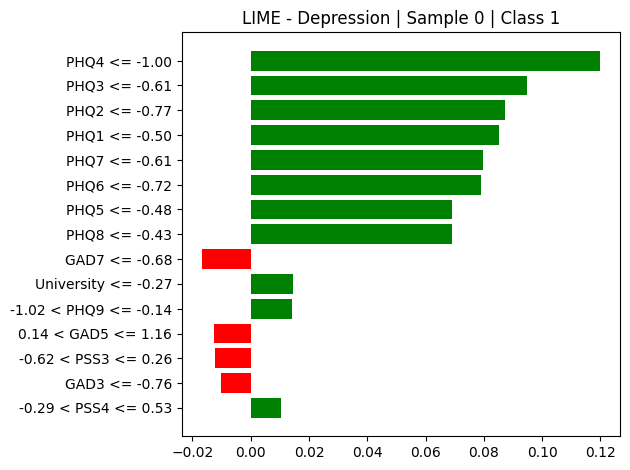

In [ ]:
# =========================================================
# 20. LIME Explanation
# =========================================================

!pip install lime

from lime.lime_tabular import LimeTabularExplainer

class_names = ["0", "1", "2", "3"]

lime_explainer = LimeTabularExplainer(
    training_data=X_train_all,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True
)

sample_idx = 0
sample_row = X_test_all[sample_idx]

lime_exp_anx = lime_explainer.explain_instance(
    data_row=sample_row,
    predict_fn=predict_anxiety_proba,
    num_features=min(15, len(feature_names)),
    top_labels=4
)

predicted_class_anx = np.argmax(predict_anxiety_proba(sample_row.reshape(1, -1))[0])

print("\n===== LIME Anxiety Explanation =====")
print("Predicted Anxiety Class:", predicted_class_anx)
print(lime_exp_anx.as_list(label=predicted_class_anx))

fig = lime_exp_anx.as_pyplot_figure(label=predicted_class_anx)
plt.title(f"LIME - Anxiety | Sample {sample_idx} | Class {predicted_class_anx}")
plt.tight_layout()
plt.show()

lime_exp_dep = lime_explainer.explain_instance(
    data_row=sample_row,
    predict_fn=predict_depression_proba,
    num_features=min(15, len(feature_names)),
    top_labels=4
)

predicted_class_dep = np.argmax(predict_depression_proba(sample_row.reshape(1, -1))[0])

print("\n===== LIME Depression Explanation =====")
print("Predicted Depression Class:", predicted_class_dep)
print(lime_exp_dep.as_list(label=predicted_class_dep))

fig = lime_exp_dep.as_pyplot_figure(label=predicted_class_dep)
plt.title(f"LIME - Depression | Sample {sample_idx} | Class {predicted_class_dep}")
plt.tight_layout()
plt.show()



In [ ]:
# =========================================================
# 20. LIME Explanation Reflecting Proposed Model Output
# =========================================================

!pip install lime

import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import torch

In [ ]:
# Combine symptom + demographic features
X_train_all = np.concatenate([X_train_symptom, X_train_demo], axis=1)
X_test_all = np.concatenate([X_test_symptom, X_test_demo], axis=1)

symptom_dim = X_train_symptom.shape[1]
demo_dim = X_train_demo.shape[1]

feature_names = list(symptom_cols) + list(demo_cols)

anxiety_class_names = [
    "Minimal Anxiety",
    "Mild Anxiety",
    "Moderate Anxiety",
    "Severe Anxiety"
]

depression_class_names = [
    "No/Minimal Depression",
    "Mild Depression",
    "Moderate Depression",
    "Severe Depression"
]

# =========================================================
# Convert proposed model ordinal logits into class probabilities
# =========================================================

def ordinal_logits_to_probs(logits):
    """
    Convert ordinal logits [B, 3] into 4-class probabilities.
    Output: [B, 4]
    """
    cum_probs = torch.sigmoid(logits)

    p0 = 1.0 - cum_probs[:, 0]
    p1 = cum_probs[:, 0] - cum_probs[:, 1]
    p2 = cum_probs[:, 1] - cum_probs[:, 2]
    p3 = cum_probs[:, 2]

    probs = torch.stack([p0, p1, p2, p3], dim=1)
    probs = torch.clamp(probs, min=1e-8)
    probs = probs / probs.sum(dim=1, keepdim=True)

    return probs


def proposed_model_predict_proba(X_flat, task="anxiety"):
    """
    Wrapper for LIME.
    Input: flat tabular input [symptom + demo]
    Output: class probabilities from proposed ConvTransformer model
    """
    conv_transformer_model.eval()

    X_flat = np.asarray(X_flat, dtype=np.float32)

    x_symptom = torch.tensor(
        X_flat[:, :symptom_dim],
        dtype=torch.float32
    ).to(device)

    x_demo = torch.tensor(
        X_flat[:, symptom_dim:],
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():
        anx_logits, dep_logits = conv_transformer_model(x_symptom, x_demo)

        if task == "anxiety":
            probs = ordinal_logits_to_probs(anx_logits)
        elif task == "depression":
            probs = ordinal_logits_to_probs(dep_logits)
        else:
            raise ValueError("task must be 'anxiety' or 'depression'")

    return probs.cpu().numpy()


def proposed_model_predict_class(X_flat, task="anxiety"):
    """
    Proposed model class output using the same ordinal decoding used in evaluation.
    """
    conv_transformer_model.eval()

    X_flat = np.asarray(X_flat, dtype=np.float32)

    x_symptom = torch.tensor(
        X_flat[:, :symptom_dim],
        dtype=torch.float32
    ).to(device)

    x_demo = torch.tensor(
        X_flat[:, symptom_dim:],
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():
        anx_logits, dep_logits = conv_transformer_model(x_symptom, x_demo)

        if task == "anxiety":
            pred = logits_to_class(anx_logits)
        elif task == "depression":
            pred = logits_to_class(dep_logits)
        else:
            raise ValueError("task must be 'anxiety' or 'depression'")

    return pred.cpu().numpy()


# =========================================================
# LIME Explainers
# =========================================================

lime_explainer_anx = LimeTabularExplainer(
    training_data=X_train_all,
    feature_names=feature_names,
    class_names=anxiety_class_names,
    mode="classification",
    discretize_continuous=True
)

lime_explainer_dep = LimeTabularExplainer(
    training_data=X_train_all,
    feature_names=feature_names,
    class_names=depression_class_names,
    mode="classification",
    discretize_continuous=True
)

# =========================================================
# Select test sample
# =========================================================

sample_idx = 0
sample = X_test_all[sample_idx]

true_anx = int(y_test_anx[sample_idx])
true_dep = int(y_test_dep[sample_idx])

pred_anx = proposed_model_predict_class(sample.reshape(1, -1), task="anxiety")[0]
pred_dep = proposed_model_predict_class(sample.reshape(1, -1), task="depression")[0]

anx_probs = proposed_model_predict_proba(sample.reshape(1, -1), task="anxiety")[0]
dep_probs = proposed_model_predict_proba(sample.reshape(1, -1), task="depression")[0]

# =========================================================
# Explain predicted class from proposed model
# =========================================================

exp_anx = lime_explainer_anx.explain_instance(
    data_row=sample,
    predict_fn=lambda x: proposed_model_predict_proba(x, task="anxiety"),
    num_features=15,
    labels=[pred_anx]
)

exp_dep = lime_explainer_dep.explain_instance(
    data_row=sample,
    predict_fn=lambda x: proposed_model_predict_proba(x, task="depression"),
    num_features=15,
    labels=[pred_dep]
)

# =========================================================
# Print model output + LIME explanation
# =========================================================

print("=" * 80)
print("PROPOSED MODEL OUTPUT - ANXIETY")
print("=" * 80)
print("Sample index:", sample_idx)
print("True class     :", anxiety_class_names[true_anx])
print("Predicted class:", anxiety_class_names[pred_anx])
print("\nClass probabilities:")
for cls_name, prob in zip(anxiety_class_names, anx_probs):
    print(f"{cls_name}: {prob:.4f}")

print("\nLIME explanation for predicted Anxiety class:")
print(exp_anx.as_list(label=pred_anx))

print("\n" + "=" * 80)
print("PROPOSED MODEL OUTPUT - DEPRESSION")
print("=" * 80)
print("Sample index:", sample_idx)
print("True class     :", depression_class_names[true_dep])
print("Predicted class:", depression_class_names[pred_dep])
print("\nClass probabilities:")
for cls_name, prob in zip(depression_class_names, dep_probs):
    print(f"{cls_name}: {prob:.4f}")

print("\nLIME explanation for predicted Depression class:")
print(exp_dep.as_list(label=pred_dep))

# =========================================================
# Notebook visual output
# =========================================================

plt.rcParams.update({
    'font.size': 4 #Define Text size
})

exp_anx.show_in_notebook(show_table=True, labels=[pred_anx])
exp_dep.show_in_notebook(show_table=True, labels=[pred_dep])

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# =========================================================
# 21. Memory-Safe SHAP Explanation for Proposed Model
# =========================================================

!pip install shap

import shap
import gc
import numpy as np
import pandas as pd
import torch

In [ ]:
# =========================================================
# 23. Final Summary Result Table
# =========================================================

final_summary = pd.DataFrame([
    {
        "Experiment": "Single Split",
        "Task": "Anxiety",
        "Accuracy": f"{single_results['anxiety']['accuracy']:.4f}",
        "Precision": f"{single_results['anxiety']['precision']:.4f}",
        "Recall": f"{single_results['anxiety']['recall']:.4f}",
        "F1 Score": f"{single_results['anxiety']['macro_f1']:.4f}"
    },
    {
        "Experiment": "Single Split",
        "Task": "Depression",
        "Accuracy": f"{single_results['depression']['accuracy']:.4f}",
        "Precision": f"{single_results['depression']['precision']:.4f}",
        "Recall": f"{single_results['depression']['recall']:.4f}",
        "F1 Score": f"{single_results['depression']['macro_f1']:.4f}"
    },
    {
        "Experiment": "5-Fold CV",
        "Task": "Anxiety",
        "Accuracy": final_cv_table.loc[final_cv_table["Task"] == "Anxiety", "Accuracy"].values[0],
        "Precision": final_cv_table.loc[final_cv_table["Task"] == "Anxiety", "Precision"].values[0],
        "Recall": final_cv_table.loc[final_cv_table["Task"] == "Anxiety", "Recall"].values[0],
        "F1 Score": final_cv_table.loc[final_cv_table["Task"] == "Anxiety", "F1 Score"].values[0]
    },
    {
        "Experiment": "5-Fold CV",
        "Task": "Depression",
        "Accuracy": final_cv_table.loc[final_cv_table["Task"] == "Depression", "Accuracy"].values[0],
        "Precision": final_cv_table.loc[final_cv_table["Task"] == "Depression", "Precision"].values[0],
        "Recall": final_cv_table.loc[final_cv_table["Task"] == "Depression", "Recall"].values[0],
        "F1 Score": final_cv_table.loc[final_cv_table["Task"] == "Depression", "F1 Score"].values[0]
    }
])

print("\n===== FINAL SUMMARY RESULT TABLE =====")
print(final_summary)

final_summary.to_csv("final_summary_results.csv", index=False)
cv_results_df.to_csv("five_fold_cv_results.csv", index=False)
history_df.to_csv("training_history.csv", index=False)

print("\nSaved files:")
print("final_summary_results.csv")
print("five_fold_cv_results.csv")
print("training_history.csv")
print("top_shap_anxiety.csv")
print("top_shap_depression.csv")


===== FINAL SUMMARY RESULT TABLE =====
     Experiment        Task         Accuracy        Precision  \
0  Single Split     Anxiety           0.9827           0.9804   
1  Single Split  Depression           0.9852           0.9792   
2     5-Fold CV     Anxiety  0.9862 ± 0.0054  0.9798 ± 0.0116   
3     5-Fold CV  Depression  0.9792 ± 0.0038  0.9710 ± 0.0108   

            Recall         F1 Score  
0           0.9850           0.9825  
1           0.9859           0.9825  
2  0.9875 ± 0.0053  0.9833 ± 0.0085  
3  0.9787 ± 0.0050  0.9744 ± 0.0082  

Saved files:
final_summary_results.csv
five_fold_cv_results.csv
training_history.csv
top_shap_anxiety.csv
top_shap_depression.csv


Important note: keep MODE = "assessment" if your goal is questionnaire-based severity assessment. Use MODE = "strict" only if you want to remove direct psychometric overlap and test a stricter stress-guided setup.